# NDP Nginx Log Analysis

This notebook analyzes the Nginx log file to answer:
- How many unique users accessed the system?
- How many datasets were accessed, counted uniquely?
- How many searches were made?

In [1]:
! pip install -q pandas matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Read the log file
log_file = 'ndp.log'

with open(log_file, 'r') as f:
    log_lines = f.readlines()

print(f"Total log entries: {len(log_lines)}")

Total log entries: 3447


In [4]:
# Parse log entries
# Log format: IP - - [timestamp] "request" status size "referer" "user-agent" "real-ip"

log_pattern = re.compile(
    r'^(\S+)\s+-\s+-\s+\[([^\]]+)\]\s+"(\S+)\s+(\S+)\s+([^"]+)"\s+(\d+)\s+(\d+)\s+"([^"]*)"\s+"([^"]*)"\s+"([^"]*)"'
)

parsed_logs = []
for line in log_lines:
    match = log_pattern.match(line.strip())
    if match:
        parsed_logs.append({
            'ip': match.group(1),
            'timestamp': match.group(2),
            'method': match.group(3),
            'path': match.group(4),
            'protocol': match.group(5),
            'status': int(match.group(6)),
            'size': int(match.group(7)),
            'referer': match.group(8),
            'user_agent': match.group(9),
            'real_ip': match.group(10)
        })

df = pd.DataFrame(parsed_logs)
print(f"Successfully parsed {len(df)} log entries")
df.head()

Successfully parsed 3447 log entries


,ip,timestamp,method,path,protocol,status,size,referer,user_agent,real_ip
0,192.168.176.1,22/Nov/2025:00:52:38 +0000,GET,/api/search/advanced/openalex/1/3/AND/null/nul...,HTTP/1.1,200,73,https://nationaldataplatform.org/workspaces/24...,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,137.110.34.232
1,192.168.176.1,22/Nov/2025:03:54:37 +0000,GET,/api/auth/callback/keycloak?state=rr94FzlEqc6N...,HTTP/1.1,302,5,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,75.80.101.234
2,192.168.176.1,22/Nov/2025:04:22:30 +0000,GET,/api/dataset/interagency-tracking-system-ifprs...,HTTP/1.1,200,1279,https://nationaldataplatform.org/dataset/inter...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,76.176.195.71
3,192.168.176.1,22/Nov/2025:04:23:16 +0000,GET,/api/auth/callback/keycloak?state=-azl5djxM_K9...,HTTP/1.1,302,5,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,76.176.195.71
4,192.168.176.1,22/Nov/2025:04:23:29 +0000,GET,/api/dataset/sdge-gridded-weather-station-wind...,HTTP/1.1,200,5192,https://nationaldataplatform.org/dataset/sdge-...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,76.176.195.71


In [5]:
# Convert timestamp to datetime
df['datetime'] = pd.to_datetime(df['timestamp'], format='%d/%b/%Y:%H:%M:%S %z')
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour

# Use real_ip for user identification (more accurate than the proxy IP)
df['user_ip'] = df['real_ip']

print("Data preprocessing complete")
df[['datetime', 'user_ip', 'method', 'path', 'status']].head()

Data preprocessing complete


,datetime,user_ip,method,path,status
0,2025-11-22 00:52:38+00:00,137.110.34.232,GET,/api/search/advanced/openalex/1/3/AND/null/nul...,200
1,2025-11-22 03:54:37+00:00,75.80.101.234,GET,/api/auth/callback/keycloak?state=rr94FzlEqc6N...,302
2,2025-11-22 04:22:30+00:00,76.176.195.71,GET,/api/dataset/interagency-tracking-system-ifprs...,200
3,2025-11-22 04:23:16+00:00,76.176.195.71,GET,/api/auth/callback/keycloak?state=-azl5djxM_K9...,302
4,2025-11-22 04:23:29+00:00,76.176.195.71,GET,/api/dataset/sdge-gridded-weather-station-wind...,200


## Question 1: How many unique users accessed the system?

In [6]:
# Count unique users based on IP addresses
unique_users = df['user_ip'].nunique()
print(f"\n👥 Unique users: {unique_users}")

# Show top users by request count
user_activity = df['user_ip'].value_counts().head(10)
print("\nTop 10 users by request count:")
print(user_activity)


👥 Unique users: 411

Top 10 users by request count:
user_ip
172.251.25.16     303
76.176.195.71     219
68.8.71.237       216
146.75.175.81     105
76.33.41.113       95
68.7.130.42        76
70.95.81.226       72
76.249.138.252     71
73.34.74.148       64
146.75.175.80      55
Name: count, dtype: int64


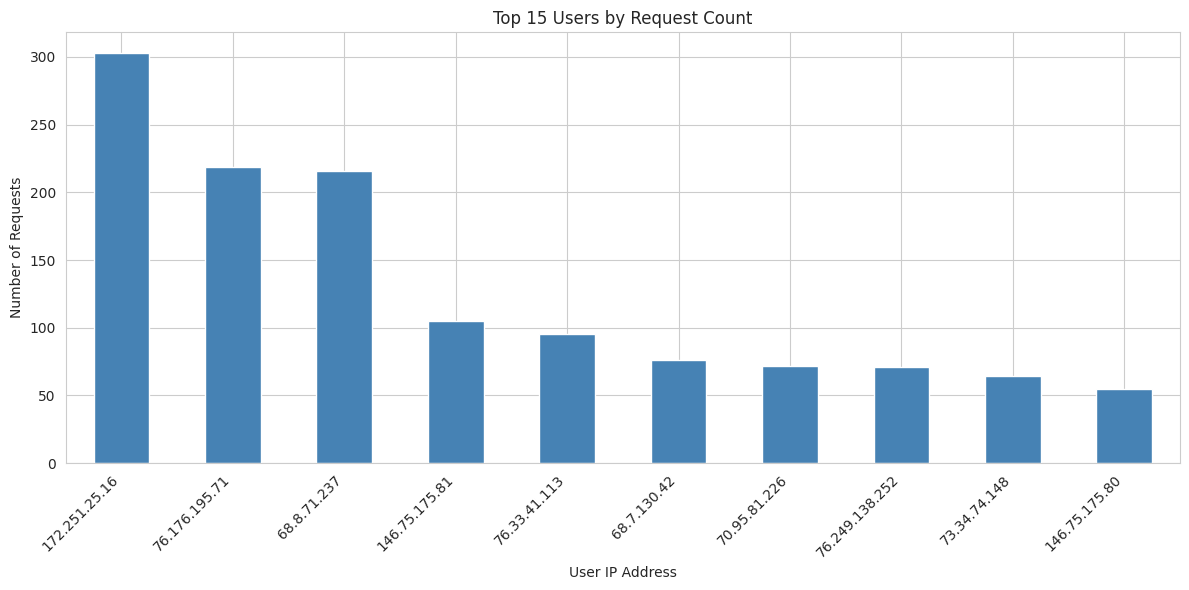

In [7]:
# Visualize user activity
plt.figure(figsize=(12, 6))
user_activity.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Users by Request Count')
plt.xlabel('User IP Address')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Question 2: How many datasets were accessed, counted uniquely?

In [8]:
# Extract dataset accesses from paths like /api/dataset/{dataset-name}
dataset_pattern = re.compile(r'^/api/dataset/([^/]+)$')

dataset_accesses = []
for idx, row in df.iterrows():
    match = dataset_pattern.match(row['path'])
    if match:
        dataset_accesses.append({
            'dataset': match.group(1),
            'user_ip': row['user_ip'],
            'datetime': row['datetime']
        })

dataset_df = pd.DataFrame(dataset_accesses)
unique_datasets = dataset_df['dataset'].nunique()

print(f"\n📊 Unique datasets accessed: {unique_datasets}")
print(f"Total dataset access events: {len(dataset_df)}")


📊 Unique datasets accessed: 339
Total dataset access events: 921


In [9]:
# Show most accessed datasets
dataset_counts = dataset_df['dataset'].value_counts().head(15)
print("\nTop 15 most accessed datasets:")
print(dataset_counts)


Top 15 most accessed datasets:
dataset
midrc-data-commons                                                                                 30
terrestrial-lidar-scans-tls-and-derived-tree-lists-for-field-sampled-plots-for-uc-climate-actio    29
cimis-hourly-data-multiple-stations                                                                23
nass-census-of-agriculture                                                                         21
high-resolution-canopy-height-maps-by-wri-and-meta                                                 18
ca_alamedacounty_2021_b21                                                                          13
intelimon-interactive-viewer                                                                       13
me_crownofmaine_2018_a18                                                                           12
weather-station-measurements                                                                       11
ca_az_fema_r9_lidar_2017_d18              

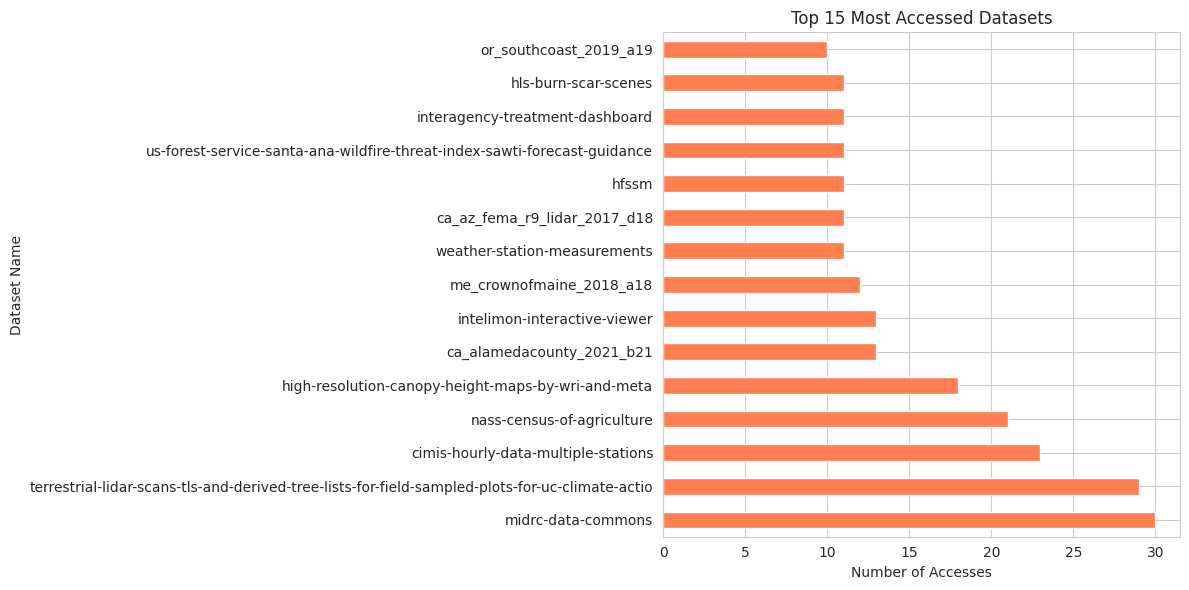

In [10]:
# Visualize dataset access patterns
plt.figure(figsize=(12, 6))
dataset_counts.head(15).plot(kind='barh', color='coral')
plt.title('Top 15 Most Accessed Datasets')
plt.xlabel('Number of Accesses')
plt.ylabel('Dataset Name')
plt.tight_layout()
plt.show()

## Question 3: How many searches were made?

In [11]:
# Extract search requests from paths like /api/search/advanced/...
search_pattern = re.compile(r'^/api/search/advanced/')

search_requests = df[df['path'].str.match(search_pattern, na=False)]
total_searches = len(search_requests)

print(f"\n🔍 Total searches made: {total_searches}")


🔍 Total searches made: 781


In [12]:
# Analyze search patterns
print("\nSearch request breakdown:")
print(f"- GET requests: {len(search_requests[search_requests['method'] == 'GET'])}")
print(f"- POST requests: {len(search_requests[search_requests['method'] == 'POST'])}")

# Show unique search paths
unique_search_paths = search_requests['path'].nunique()
print(f"- Unique search query patterns: {unique_search_paths}")


Search request breakdown:
- GET requests: 781
- POST requests: 0
- Unique search query patterns: 535


In [ ]:
# Visualize searches over time
search_requests['date'] = search_requests['datetime'].dt.date
searches_by_date = search_requests.groupby('date').size()

plt.figure(figsize=(12, 6))
searches_by_date.plot(kind='line', marker='o', color='green')
plt.title('Searches Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Searches')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Additional Analysis

In [ ]:
# Request types distribution
request_types = df['method'].value_counts()
print("\nRequest types:")
print(request_types)

In [ ]:
# Status code distribution
status_codes = df['status'].value_counts().sort_index()
print("\nStatus code distribution:")
print(status_codes)

In [ ]:
# Visualize status codes
plt.figure(figsize=(10, 6))
status_codes.plot(kind='bar', color='purple')
plt.title('HTTP Status Code Distribution')
plt.xlabel('Status Code')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Activity by hour of day
activity_by_hour = df.groupby('hour').size()

plt.figure(figsize=(12, 6))
activity_by_hour.plot(kind='bar', color='teal')
plt.title('Activity by Hour of Day')
plt.xlabel('Hour (UTC)')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Summary

In [ ]:
print("="*60)
print("NDP LOG ANALYSIS SUMMARY")
print("="*60)
print(f"📅 Log period: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"📝 Total log entries: {len(df)}")
print(f"\n👥 Unique users: {unique_users}")
print(f"📊 Unique datasets accessed: {unique_datasets}")
print(f"🔍 Total searches made: {total_searches}")
print(f"\n📈 Average requests per user: {len(df) / unique_users:.2f}")
print(f"📈 Average datasets per user: {len(dataset_df) / unique_users:.2f}")
print(f"📈 Average searches per user: {total_searches / unique_users:.2f}")
print("="*60)